In [1]:
# Import the required library
import polars as pl 

In [2]:
# Load the dataset
import polars as pl

df = pl.read_csv(
    "../data/Maternal Health Risk Data Set.csv",
    schema_overrides={
        "Age": pl.Int64,
        "SystolicBP": pl.Int64,
        "DiastolicBP": pl.Int64,
        "BS": pl.Float64,
        "BodyTemp": pl.Float64,
        "HeartRate": pl.Int64,
        "RiskLevel": pl.String
    }
)

print(df.schema)

Schema({'Age': Int64, 'SystolicBP': Int64, 'DiastolicBP': Int64, 'BS': Float64, 'BodyTemp': Float64, 'HeartRate': Int64, 'RiskLevel': String})


In [3]:
# Display the first five rows
df.head()

Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
i64,i64,i64,f64,f64,i64,str
25,130,80,15.0,98.0,86,"""high risk"""
35,140,90,13.0,98.0,70,"""high risk"""
29,90,70,8.0,100.0,80,"""high risk"""
30,140,85,7.0,98.0,70,"""high risk"""
35,120,60,6.1,98.0,76,"""low risk"""


In [4]:
# Display the shape of the dataset
df.shape

(1014, 7)

In [5]:
# Display the column names
df.columns

['Age',
 'SystolicBP',
 'DiastolicBP',
 'BS',
 'BodyTemp',
 'HeartRate',
 'RiskLevel']

In [6]:
# Generate summary statistics
df.describe()

statistic,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
str,f64,f64,f64,f64,f64,f64,str
"""count""",1014.0,1014.0,1014.0,1014.0,1014.0,1014.0,"""1014"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,null
"""std""",13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,null
"""min""",10.0,70.0,49.0,6.0,98.0,7.0,"""high risk"""
"""25%""",19.0,100.0,65.0,6.9,98.0,70.0,null
"""50%""",26.0,120.0,80.0,7.5,98.0,76.0,null
"""75%""",39.0,120.0,90.0,8.0,98.0,80.0,null
"""max""",70.0,160.0,100.0,19.0,103.0,90.0,"""mid risk"""


In [7]:
# Check for missing values
df.null_count()

Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0


In [8]:
# Count the number of records in each risk category
df.group_by("RiskLevel").len().sort("len", descending=True)

RiskLevel,len
str,u32
"""low risk""",406
"""mid risk""",336
"""high risk""",272


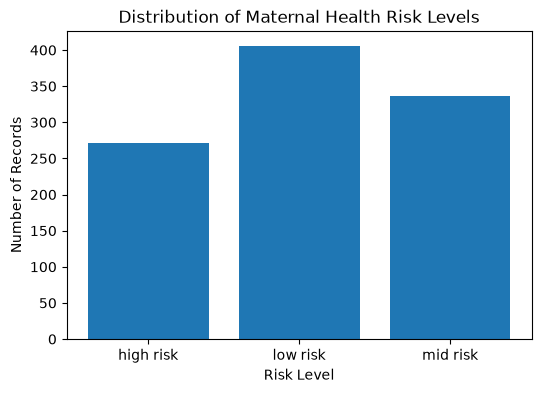

In [10]:
import matplotlib.pyplot as plt

# Count the number of records in each risk level
risk_counts = (
    df.group_by("RiskLevel")
      .len()
      .sort("RiskLevel")
)

# Extract values directly from the Polars DataFrame
risk_levels = risk_counts["RiskLevel"].to_list()
counts = risk_counts["len"].to_list()

# Create the chart
plt.figure(figsize=(6,4))
plt.bar(risk_levels, counts)

plt.title("Distribution of Maternal Health Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

In [13]:
# Check for duplicate rows
duplicate_count = df.is_duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 866


In [19]:
print("Total rows:", df.height)

Total rows: 1014


In [20]:
print("Unique rows:", df.unique().height)

Unique rows: 452


In [21]:
duplicate_rows = df.height - df.unique().height

print("Actual duplicate rows:", duplicate_rows)

Actual duplicate rows: 562


Age Distribution

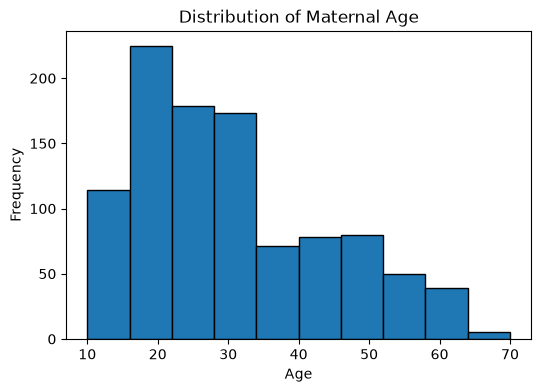

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(
    df["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Maternal Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Blood sugar distribution

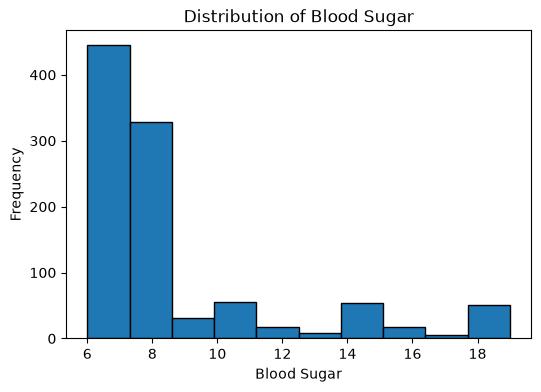

In [15]:
plt.figure(figsize=(6,4))

plt.hist(
    df["BS"].to_list(),
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Blood Sugar")

plt.xlabel("Blood Sugar")

plt.ylabel("Frequency")

plt.show()

Average Age by Risk Level

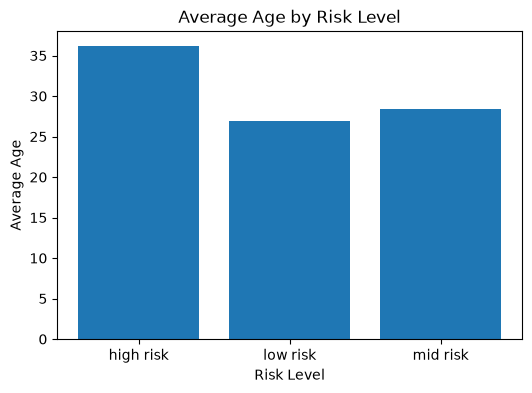

In [16]:
age_by_risk = (
    df.group_by("RiskLevel")
      .agg(pl.col("Age").mean())
      .sort("RiskLevel")
)

plt.figure(figsize=(6,4))

plt.bar(
    age_by_risk["RiskLevel"].to_list(),
    age_by_risk["Age"].to_list()
)

plt.title("Average Age by Risk Level")

plt.xlabel("Risk Level")

plt.ylabel("Average Age")

plt.show()

Average Blood sugar by Risk Level

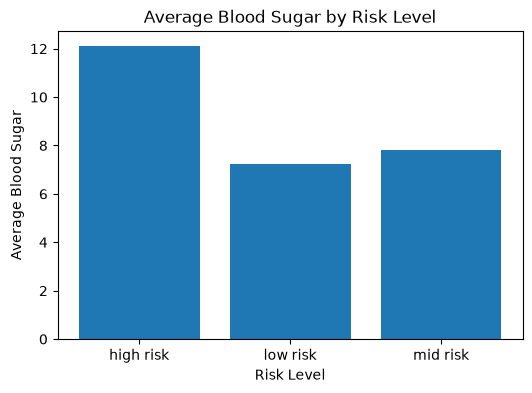

In [17]:
bs_by_risk = (
    df.group_by("RiskLevel")
      .agg(pl.col("BS").mean())
      .sort("RiskLevel")
)

plt.figure(figsize=(6,4))

plt.bar(
    bs_by_risk["RiskLevel"].to_list(),
    bs_by_risk["BS"].to_list()
)

plt.title("Average Blood Sugar by Risk Level")

plt.xlabel("Risk Level")

plt.ylabel("Average Blood Sugar")

plt.show()

Correlation Analysis

In [ ]:
# Calculate the correlation between numerical variables
correlation = df.select(
    [
        "Age",
        "SystolicBP",
        "DiastolicBP",
        "BS",
        "BodyTemp",
        "HeartRate",
    ]
).corr()

correlation

Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
f64,f64,f64,f64,f64,f64
1.0,0.416045,0.398026,0.473284,-0.255323,0.079798
0.416045,1.0,0.787006,0.425172,-0.286616,-0.023108
0.398026,0.787006,1.0,0.423824,-0.257538,-0.046151
0.473284,0.425172,0.423824,1.0,-0.103493,0.142867
-0.255323,-0.286616,-0.257538,-0.103493,1.0,0.098771
0.079798,-0.023108,-0.046151,0.142867,0.098771,1.0


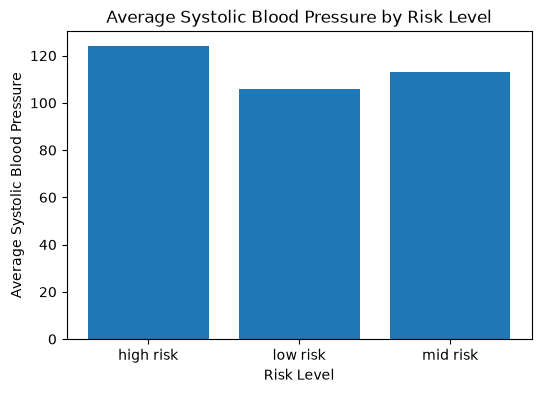

In [22]:
# Calculate average systolic blood pressure for each risk category

bp = (
    df.group_by("RiskLevel")
      .agg(pl.col("SystolicBP").mean())
      .sort("RiskLevel")
)

plt.figure(figsize=(6,4))

plt.bar(
    bp["RiskLevel"].to_list(),
    bp["SystolicBP"].to_list()
)

plt.title("Average Systolic Blood Pressure by Risk Level")

plt.xlabel("Risk Level")

plt.ylabel("Average Systolic Blood Pressure")

plt.show()

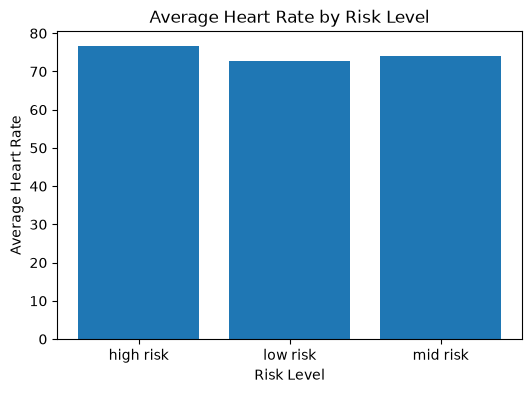

In [23]:
heart = (
    df.group_by("RiskLevel")
      .agg(pl.col("HeartRate").mean())
      .sort("RiskLevel")
)

plt.figure(figsize=(6,4))

plt.bar(
    heart["RiskLevel"].to_list(),
    heart["HeartRate"].to_list()
)

plt.title("Average Heart Rate by Risk Level")

plt.xlabel("Risk Level")

plt.ylabel("Average Heart Rate")

plt.show()

Body temperature distribution

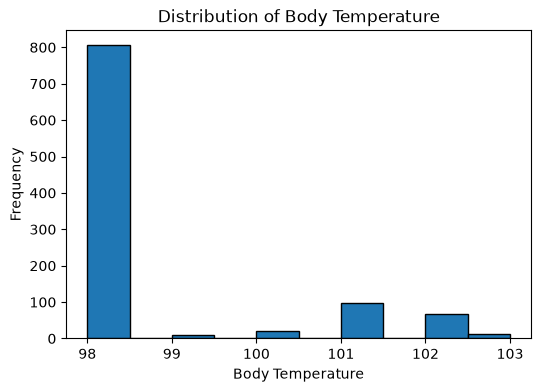

In [25]:
plt.figure(figsize=(6,4))

plt.hist(
    df["BodyTemp"].to_list(),
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Body Temperature")

plt.xlabel("Body Temperature")

plt.ylabel("Frequency")

plt.show()

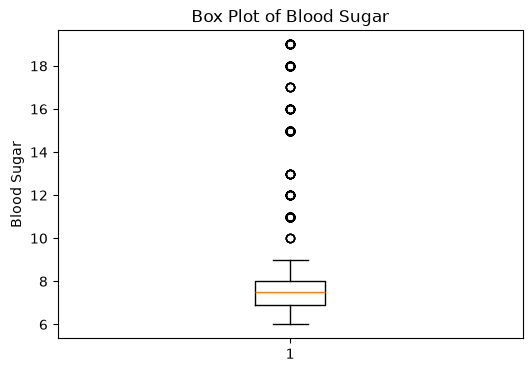

In [24]:
# Outlier Detection
plt.figure(figsize=(6,4))

plt.boxplot(df["BS"].to_list())

plt.title("Box Plot of Blood Sugar")

plt.ylabel("Blood Sugar")

plt.show()

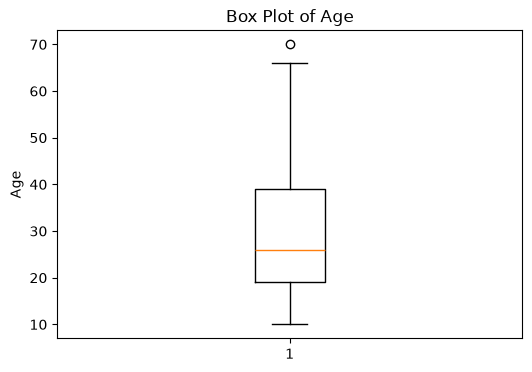

In [27]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Age"].to_list())

plt.title("Box Plot of Age")

plt.ylabel("Age")

plt.show()

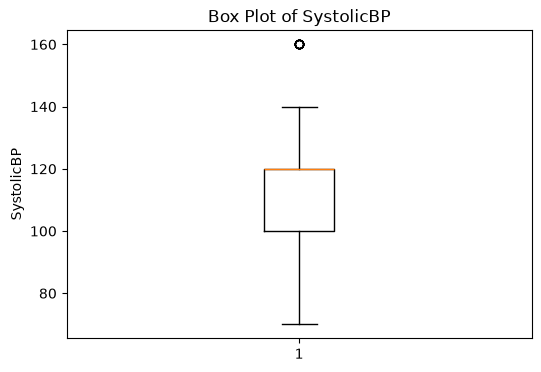

In [28]:
plt.figure(figsize=(6,4))

plt.boxplot(df["SystolicBP"].to_list())

plt.title("Box Plot of SystolicBP")

plt.ylabel("SystolicBP")

plt.show()

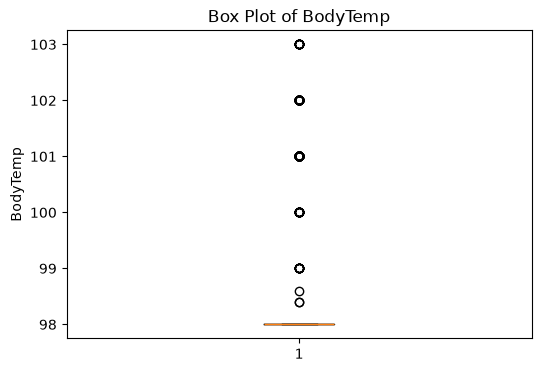

In [30]:
plt.figure(figsize=(6,4))

plt.boxplot(df["BodyTemp"].to_list())

plt.title("Box Plot of BodyTemp")

plt.ylabel("BodyTemp")

plt.show()

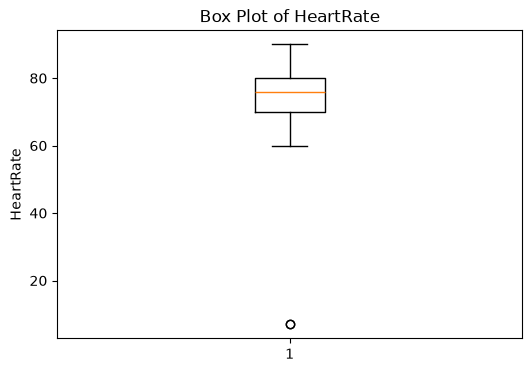

In [31]:
plt.figure(figsize=(6,4))

plt.boxplot(df["HeartRate"].to_list())

plt.title("Box Plot of HeartRate")

plt.ylabel("HeartRate")

plt.show()

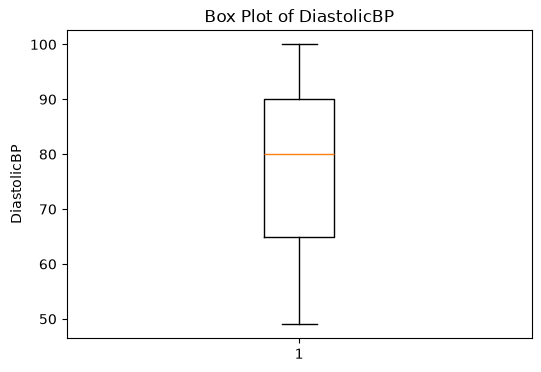

In [29]:
plt.figure(figsize=(6,4))

plt.boxplot(df["DiastolicBP"].to_list())

plt.title("Box Plot of DiastolicBP")

plt.ylabel("DiastolicBP")

plt.show()

## Key Findings

The exploratory data analysis produced the following findings:

- The dataset contains 1,014 maternal health records.
- Seven clinical variables are available for analysis.
- No missing values were identified.
- The target variable consists of three maternal risk categories.
- Blood pressure, blood sugar, body temperature, heart rate, and age all show variability that may contribute to maternal health risk prediction.
- Some repeated records exist in the dataset. Since there is no unique patient identifier, these records have been retained because they may represent different individuals with identical clinical measurements.
- The box plot analysis was performed to detect possible outliers in numerical features. Some observations were found outside the whiskers, especially in blood pressure and blood sugar measurements. These values were investigated further before deciding whether to retain or remove them because extreme medical values may represent genuine high-risk cases.
- The dataset appears suitable for developing a machine learning classification model.